<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Task-statistics" data-toc-modified-id="Task-statistics-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Task statistics</a></span></li><li><span><a href="#Train-model" data-toc-modified-id="Train-model-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Train model</a></span><ul class="toc-item"><li><span><a href="#Evaluate-performance" data-toc-modified-id="Evaluate-performance-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Evaluate performance</a></span></li></ul></li><li><span><a href="#Ratemaps" data-toc-modified-id="Ratemaps-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Ratemaps</a></span><ul class="toc-item"><li><span><a href="#Grid-scores" data-toc-modified-id="Grid-scores-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Grid scores</a></span></li></ul></li><li><span><a href="#Manifold-distance" data-toc-modified-id="Manifold-distance-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Manifold distance</a></span></li><li><span><a href="#Neural-sheet" data-toc-modified-id="Neural-sheet-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Neural sheet</a></span></li><li><span><a href="#Connectivity" data-toc-modified-id="Connectivity-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Connectivity</a></span><ul class="toc-item"><li><span><a href="#Sort-weights" data-toc-modified-id="Sort-weights-6.1"><span class="toc-item-num">6.1&nbsp;&nbsp;</span>Sort weights</a></span></li></ul></li><li><span><a href="#Path-integration" data-toc-modified-id="Path-integration-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Path integration</a></span></li><li><span><a href="#SVD" data-toc-modified-id="SVD-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>SVD</a></span></li><li><span><a href="#Null-model-(low-pass-filtered-noise)" data-toc-modified-id="Null-model-(low-pass-filtered-noise)-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Null model (low-pass filtered noise)</a></span></li><li><span><a href="#Boundary-extension" data-toc-modified-id="Boundary-extension-10"><span class="toc-item-num">10&nbsp;&nbsp;</span>Boundary extension</a></span></li><li><span><a href="#Head-direction-and-speed-tuning" data-toc-modified-id="Head-direction-and-speed-tuning-11"><span class="toc-item-num">11&nbsp;&nbsp;</span>Head direction and speed tuning</a></span></li><li><span><a href="#Border-score" data-toc-modified-id="Border-score-12"><span class="toc-item-num">12&nbsp;&nbsp;</span>Border score</a></span></li></ul></div>

In [1]:
import numpy as np
import torch

from tqdm import tqdm
from matplotlib import pyplot as plt

%load_ext autoreload
%autoreload 2

In [2]:
# If GPUs available, select which to train on
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="0"

In [3]:
from utils import generate_run_ID, load_trained_weights
from place_cells import PlaceCells
from trajectory_generator import TrajectoryGenerator
from model import RNN
from trainer import Trainer

In [4]:
# Training options and hyperparameters
class Options:
    pass
options = Options()

options.save_dir = '/mnt/fs2/bsorsch/grid_cells/models/'
options.n_steps = 100000      # number of training steps
options.batch_size = 200      # number of trajectories per batch
options.sequence_length = 20  # number of steps in trajectory
options.learning_rate = 1e-4  # gradient descent learning rate
options.Np = 512              # number of place cells
options.Ng = 4096             # number of grid cells
options.place_cell_rf = 0.12  # width of place cell center tuning curve (m)
options.surround_scale = 2    # if DoG, ratio of sigma2^2 to sigma1^2
options.RNN_type = 'RNN'      # RNN or LSTM
options.activation = 'relu'   # recurrent nonlinearity
options.weight_decay = 1e-4   # strength of weight decay on recurrent weights
options.DoG = True            # use difference of gaussians tuning curves
options.periodic = False      # trajectories with periodic boundary conditions
options.box_width = 2.2       # width of training environment
options.box_height = 2.2      # height of training environment

options.run_ID = generate_run_ID(options)

In [11]:
# If you've trained with these params before, will restore trained model
place_cells = PlaceCells(options)
model = RNN(options, place_cells).cuda()
trajectory_generator = TrajectoryGenerator(options, place_cells)
trainer = Trainer(options, model, trajectory_generator)

# # Load example weights stored on github
# weight_dir = options.save_dir + '/example_trained_weights.npy'
# load_trained_weights(model, trainer, weight_dir)

Restored trained model from /mnt/fs2/bsorsch/grid_cells/models/steps_20_batch_200_RNN_4096_relu_rf_012_DoG_True_periodic_False_lr_00001_weight_decay_00001/most_recent_model.pth


# Task statistics

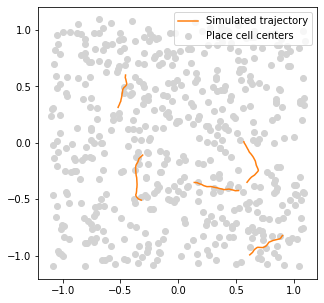

In [13]:
# Plot a few sample trajectories
inputs, pos, pc_outputs = trajectory_generator.get_test_batch()
us = place_cells.us.cpu()
pos = pos.cpu()

plt.figure(figsize=(5,5))
plt.scatter(us[:,0], us[:,1], c='lightgrey', label='Place cell centers')
for i in range(5):
    plt.plot(pos[:,i,0],pos[:,i,1], label='Simulated trajectory', c='C1')
    if i==0:
        plt.legend();

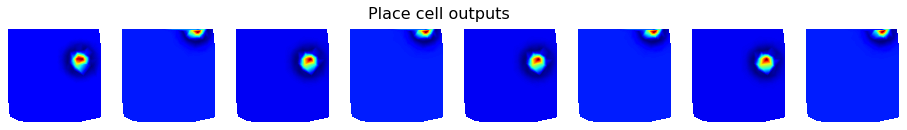

In [17]:
# Plot a few place cell outputs
pc_outputs = pc_outputs.reshape(-1, options.Np).detach().cpu()
pc = place_cells.grid_pc(pc_outputs[::100], res=100)

plt.figure(figsize=(16,2))
for i in range(8):
    plt.subplot(1,8,i+1)
    plt.imshow(pc[i], cmap='jet')
    plt.axis('off')
        
plt.suptitle('Place cell outputs', fontsize=16)
plt.show()

# plt.tight_layout()

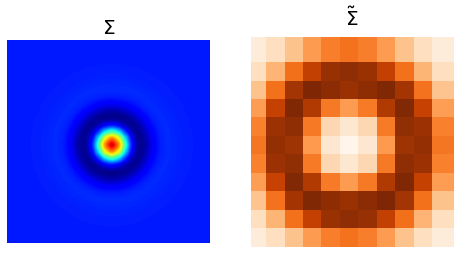

In [18]:
# Visualize place cell covariance matrix
Cmean = place_cells.compute_covariance(res=30)

# Fourier transform
Ctilde = np.fft.fft2(Cmean)
Ctilde[0,0] = 0

plt.figure(figsize=(8,4))
plt.subplot(121)
plt.imshow(Cmean, cmap='jet', interpolation='gaussian')
plt.axis('off')
plt.title(r'$\Sigma$', fontsize=20)

plt.subplot(122)
width = 6
idxs = np.arange(-width+1, width)
x2, y2 = np.meshgrid(np.arange(2*width-1), np.arange(2*width-1))
plt.scatter(x2,y2,c=np.abs(Ctilde)[idxs][:,idxs],
            s=600, cmap='Oranges', marker='s')

plt.axis('equal')
plt.axis('off')
plt.title(r'$\tilde \Sigma$', fontsize=20)
plt.axis('off');

# Train model

Step 0/100. Loss: 6.25. Err: 0.92cm


Text(0.5, 0, 'train step')

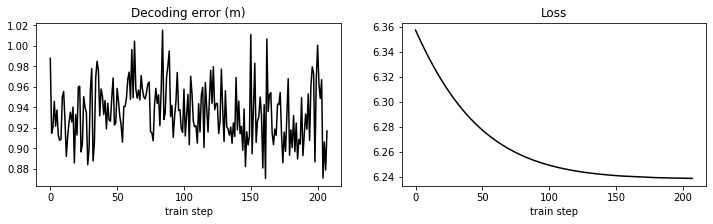

In [16]:
trainer.train(n_steps=options.n_steps, save=True)

plt.figure(figsize=(12,3))
plt.subplot(121)
plt.plot(trainer.err, c='black')

plt.title('Decoding error (m)'); plt.xlabel('train step')
plt.subplot(122)
plt.plot(trainer.loss, c='black');
plt.title('Loss'); plt.xlabel('train step');

## Evaluate performance

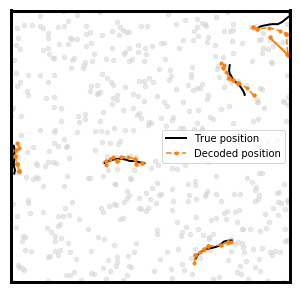

In [10]:
inputs, pos, pc_outputs = trajectory_generator.get_test_batch()
pos = pos.cpu()
pred_pos = place_cells.get_nearest_cell_pos(model.predict(inputs)).cpu()
us = place_cells.us.cpu()

fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111)
for i in range(5):
    plt.plot(pos[:,i,0], pos[:,i,1], c='black', label='True position', linewidth=2)
    plt.plot(pred_pos[:,i,0], pred_pos[:,i,1], '.-',
             c='C1', label='Decoded position')
    if i==0:
        plt.legend()
plt.scatter(us[:,0], us[:,1], s=20, alpha=0.5, c='lightgrey')
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(3)
plt.xticks([])
plt.yticks([])
plt.xlim([-options.box_width/2,options.box_width/2])
plt.ylim([-options.box_height/2,options.box_height/2]);
# plt.savefig('images/sim_traj_decode.pdf')

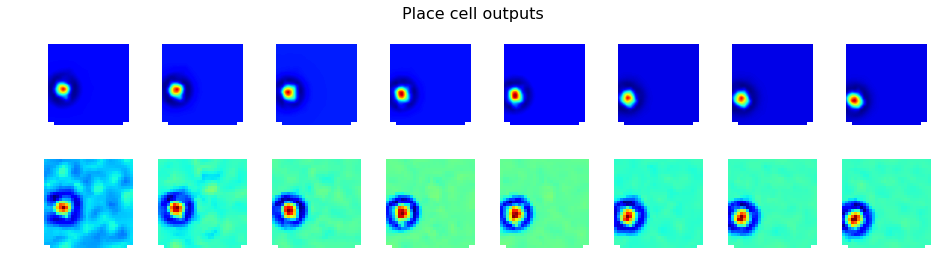

In [12]:
# Visualize predicted place cell outputs
inputs, pos, pc_outputs = trajectory_generator.get_test_batch()
preds = model.predict(inputs)
preds = preds.reshape(-1, options.Np).detach().cpu()
pc_outputs = model.softmax(pc_outputs).reshape(-1, options.Np).cpu()
pc_pred = place_cells.grid_pc(preds[:100])
pc = place_cells.grid_pc(pc_outputs[:100])

plt.figure(figsize=(16,4))
for i in range(8):
    plt.subplot(2,8,i+9)
    plt.imshow(pc_pred[2*i], cmap='jet')
    if i==0:
        plt.ylabel('Predicted')
    plt.axis('off')
    
for i in range(8):
    plt.subplot(2,8,i+1)
    plt.imshow(pc[2*i], cmap='jet', interpolation='gaussian')
    if i==0:
        plt.ylabel('True')
    plt.axis('off')
    
plt.suptitle('Place cell outputs', fontsize=16)
plt.show()

# Ratemaps

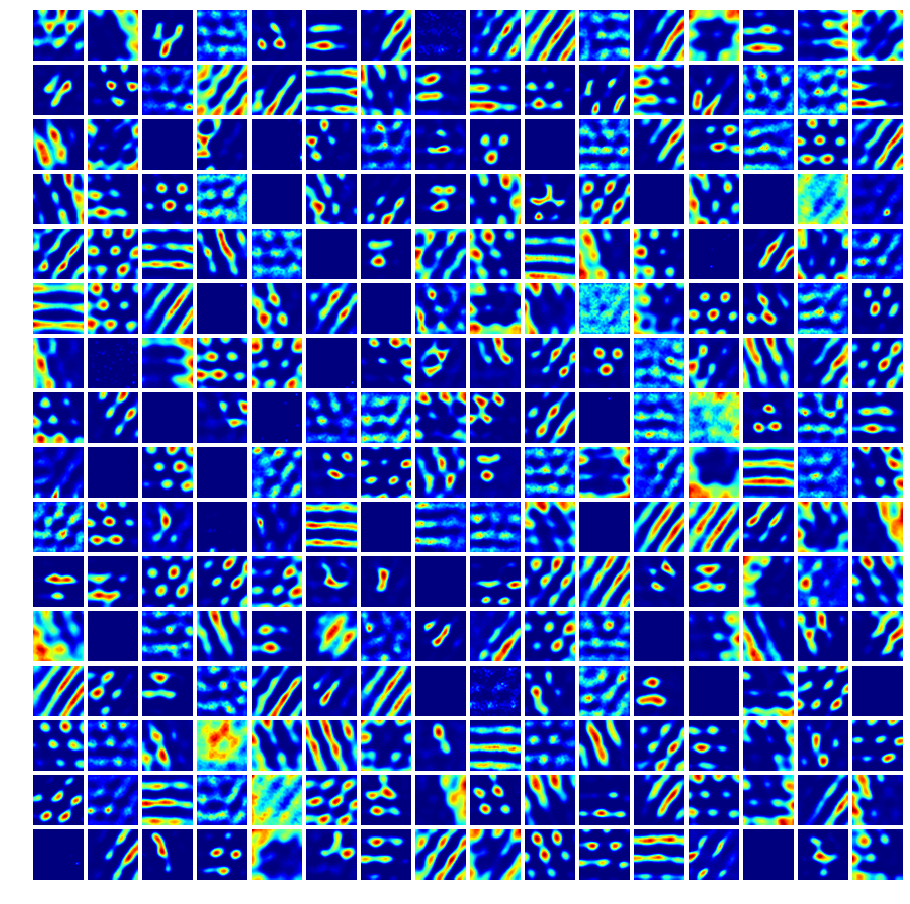

In [15]:
from visualize import compute_ratemaps, plot_ratemaps
res = 50
n_avg = 100
Ng = options.Ng
activations, rate_map, g, pos = compute_ratemaps(model,
                                                 trajectory_generator,
                                                 options,
                                                 res=res,
                                                 n_avg=n_avg,
                                                 Ng=Ng)

# Compute a set of lo-res maps to use for evalutaing grid score
lo_res = 20
_, rate_map_lores, _, _ = compute_ratemaps(model,
                                         trajectory_generator,
                                         options,
                                         res=lo_res,
                                         n_avg=n_avg,
                                         Ng=Ng)
n_plot = 256
plt.figure(figsize=(16,4*n_plot//8**2))
rm_fig = plot_ratemaps(activations, n_plot, smooth=True)
plt.imshow(rm_fig)
plt.axis('off');

## Grid scores

In [ ]:
from scores import GridScorer

starts = [0.2] * 10
ends = np.linspace(0.4, 1.0, num=10)
box_width=options.box_width
box_height=options.box_height
coord_range=((-box_width/2, box_width/2), (-box_height/2, box_height/2))
masks_parameters = zip(starts, ends.tolist())
scorer = GridScorer(res, coord_range, masks_parameters)

score_60, score_90, max_60_mask, max_90_mask, sac, max_60_ind = zip(
      *[scorer.get_scores(rm.reshape(res, res)) for rm in tqdm(rate_map_lores)])

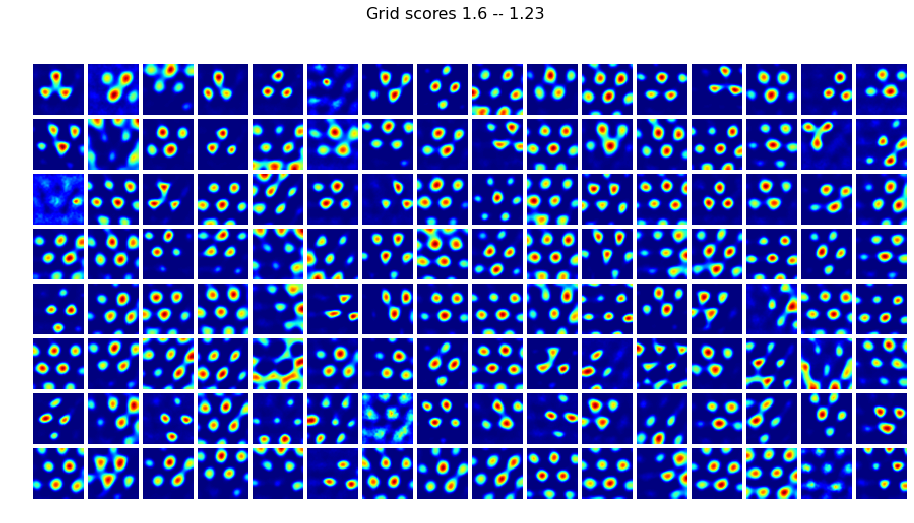

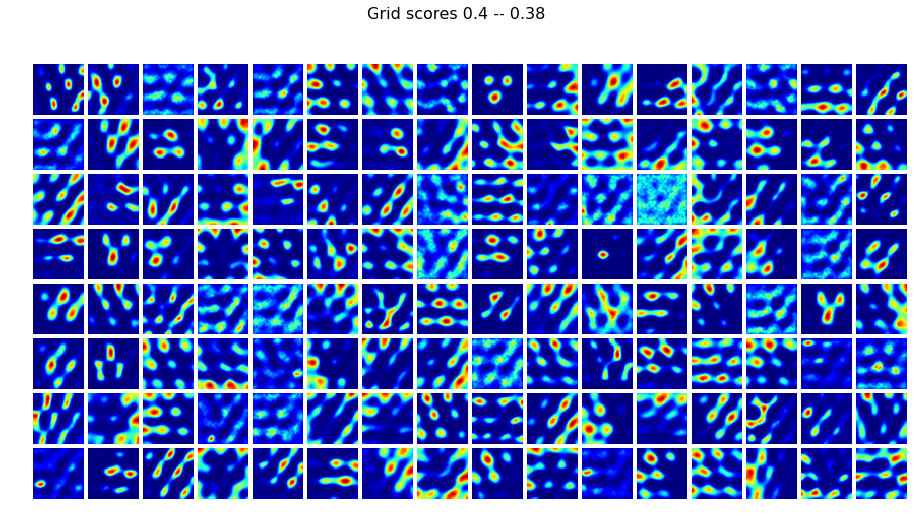

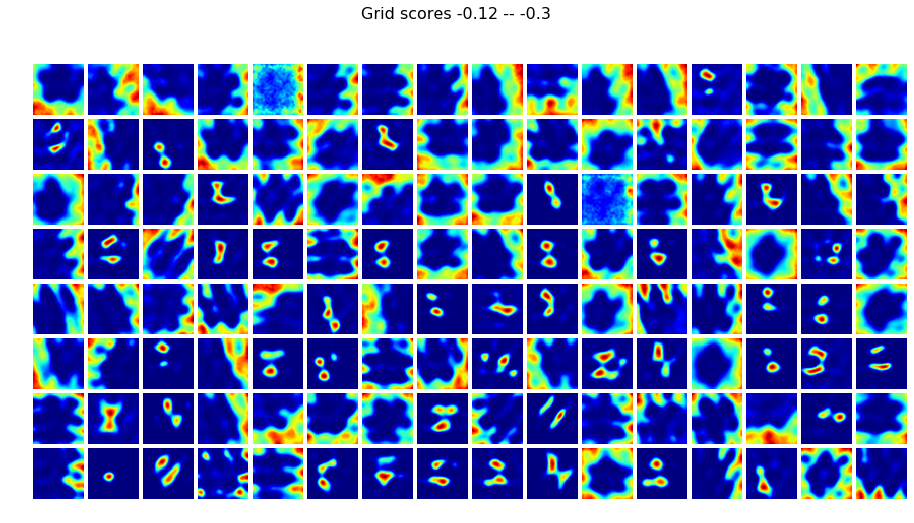

In [17]:
idxs = np.flip(np.argsort(score_60))
Ng = options.Ng

# Plot high grid scores
n_plot = 128
plt.figure(figsize=(16,4*n_plot//8**2))
rm_fig = plot_ratemaps(activations[idxs], n_plot, smooth=True)
plt.imshow(rm_fig)
plt.suptitle('Grid scores '+str(np.round(score_60[idxs[0]], 2))
             +' -- '+ str(np.round(score_60[idxs[n_plot]], 2)),
            fontsize=16)
plt.axis('off');

# Plot medium grid scores
plt.figure(figsize=(16,4*n_plot//8**2))
rm_fig = plot_ratemaps(activations[idxs[Ng//4:]], n_plot, smooth=True)
plt.imshow(rm_fig)
plt.suptitle('Grid scores '+str(np.round(score_60[idxs[Ng//2]], 2))
             +' -- ' + str(np.round(score_60[idxs[Ng//2+n_plot]], 2)),
            fontsize=16)
plt.axis('off');

# Plot low grid scores
plt.figure(figsize=(16,4*n_plot//8**2))
rm_fig = plot_ratemaps(activations[np.flip(idxs)], n_plot, smooth=True)
plt.imshow(rm_fig)
plt.suptitle('Grid scores '+str(np.round(score_60[idxs[-n_plot]], 2))
             +' -- ' + str(np.round(score_60[idxs[-1]], 2)),
            fontsize=16)
plt.axis('off');

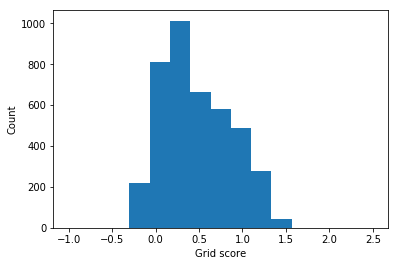

In [18]:
plt.hist(score_60, range=(-1,2.5), bins=15);
plt.xlabel('Grid score')
plt.ylabel('Count');

# Manifold distance

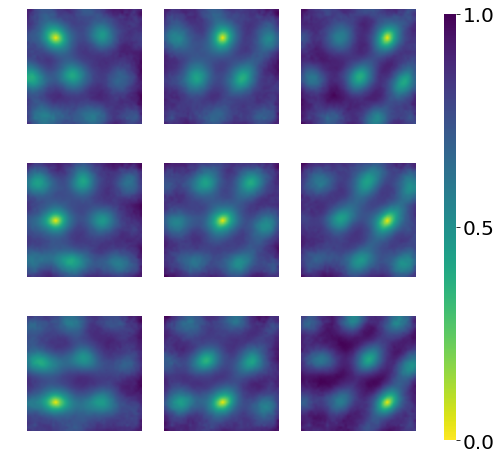

In [21]:
# Keeping all grid cells
origins = np.stack(np.mgrid[:3,:3] - 1) * res//4 + res//2

fig = plt.figure(figsize=(8,8))
for i in range(3):
    for j in range(3):
        plt.subplot(3,3,3*i+j+1)
        origin=np.random.randint(0,100,2)
        origin_idx = np.ravel_multi_index((origins[0,i,j],origins[1,i,j]), (res,res))
        r0 = rate_map[:,origin_idx,None]
        dists = np.linalg.norm(r0 - rate_map, axis=0)
        im = plt.imshow(dists.reshape(res,res)/np.max(dists),
                        cmap='viridis_r', interpolation='gaussian')
        plt.axis('off')
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.12, 0.02, 0.74])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.ax.locator_params(nbins=3)
cbar.ax.tick_params(labelsize=20) 
cbar.outline.set_visible(False)

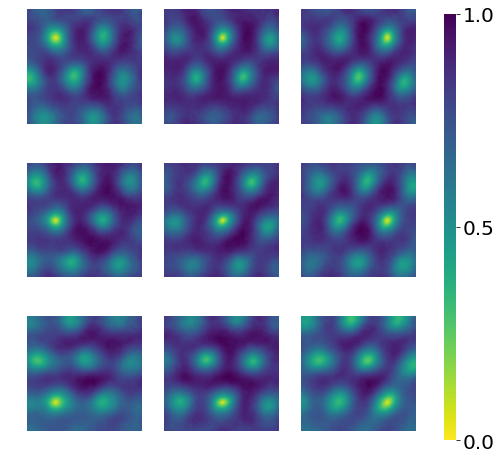

In [22]:
# Keeping only top 500 grid cells
n_grid_cells = 500
grid_sort = np.flip(np.argsort(score_60))
origins = np.stack(np.mgrid[:3,:3] - 1) * res//4 + res//2

fig = plt.figure(figsize=(8,8))
for i in range(3):
    for j in range(3):
        plt.subplot(3,3,3*i+j+1)
        origin=np.random.randint(0,100,2)
        origin_idx = np.ravel_multi_index((origins[0,i,j],origins[1,i,j]), (res,res))
        r0 = rate_map[grid_sort[:n_grid_cells],origin_idx,None]
        dists = np.linalg.norm(r0 - rate_map[grid_sort[:n_grid_cells]], axis=0)
        im = plt.imshow(dists.reshape(res,res)/np.max(dists),
                        cmap='viridis_r', interpolation='gaussian')
        plt.axis('off')
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.12, 0.02, 0.74])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.ax.locator_params(nbins=3)
cbar.ax.tick_params(labelsize=20) 
cbar.outline.set_visible(False)

# Neural sheet

In [ ]:
# Fourier transform 
Ng = options.Ng
rm_fft_real = np.zeros([Ng,res,res])
rm_fft_imag = np.zeros([Ng,res,res])

for i in tqdm(range(Ng)):
    rm_fft_real[i] = np.real(np.fft.fft2(rate_map[i].reshape([res,res])))
    rm_fft_imag[i] = np.imag(np.fft.fft2(rate_map[i].reshape([res,res])))
    
rm_fft = rm_fft_real + 1j * rm_fft_imag

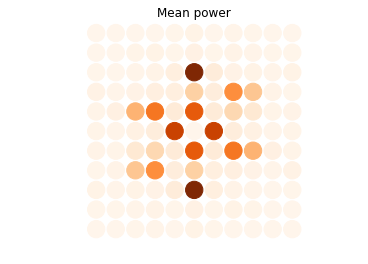

In [25]:
width = 6
idxs = np.arange(-width+1, width)
x2, y2 = np.meshgrid(np.arange(2*width-1), np.arange(2*width-1))
im = (np.real(rm_fft)**2).mean(0)
im[0,0] = 0
plt.scatter(x2,y2,c=im[idxs][:,idxs], s=300, cmap='Oranges')
plt.axis('equal')
plt.axis('off');
plt.title('Mean power');

In [26]:
k1 = [3,0]
k2 = [2,3]
k3 = [-1,3]
k4=k5=k6=k1

freq = 1
ks = freq*np.array([k1,k2,k3,k4,k5,k6])
ks = ks.astype('int')

modes = np.stack([rm_fft[:,k[0],k[1]] for k in ks])

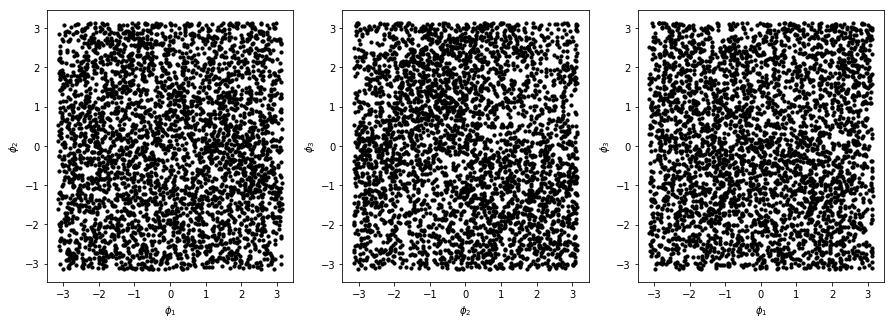

In [27]:
# Find phases
phases = [np.angle(mode) for mode in modes]

plt.figure(figsize=(15,5))
plt.subplot(131)
plt.scatter(phases[0], phases[1], c='black', s=10)
plt.xlabel(r'$\phi_1$')
plt.ylabel(r'$\phi_2$')
plt.subplot(132)
plt.scatter(phases[1], phases[2], c='black', s=10)
plt.xlabel(r'$\phi_2$')
plt.ylabel(r'$\phi_3$')
plt.subplot(133)
plt.scatter(phases[0], phases[2], c='black', s=10)
plt.xlabel(r'$\phi_1$')
plt.ylabel(r'$\phi_3$')
plt.show()

Text(0.5, 0, '$\\phi_3$')

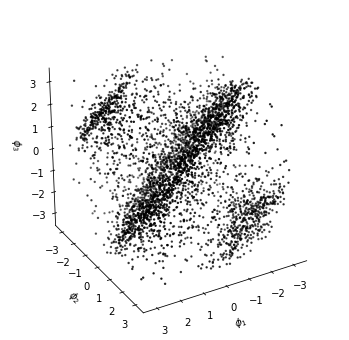

In [31]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(phases[0], phases[1], phases[2], c='black', s=2)
ax.view_init(azim=60)
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.xaxis._axinfo["grid"]['color'] =  (1,1,1,0)
ax.yaxis._axinfo["grid"]['color'] =  (1,1,1,0)
ax.zaxis._axinfo["grid"]['color'] =  (1,1,1,0)
ax.set_xlabel(r'$\phi_1$')
ax.set_ylabel(r'$\phi_2$')
ax.set_zlabel(r'$\phi_3$')

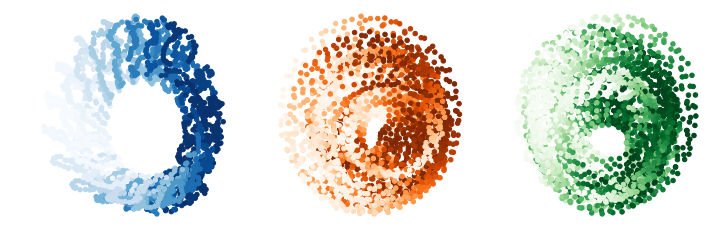

In [60]:
freq = 1
crop = 0
cmaps = ['Blues', 'Oranges', 'Greens']
x = np.mgrid[:res,:res] * 2*np.pi/ res
x = x.reshape(2, -1)
k = freq*np.stack([k1,k2,k3])
X = np.concatenate([np.cos(k.dot(x)), np.sin(k.dot(x))], axis=0)
idxs1, idxs2 = np.mgrid[crop:res-crop, crop:res-crop]
idxs = np.ravel_multi_index((idxs1,idxs2), (res,res)).ravel()

plt.figure(figsize=(12,4))
for i in range(3):
    plt.subplot(1,3,i+1)
    B = np.stack([np.cos(phases[i]), np.sin(phases[i])])
    test = B@rate_map
    plt.scatter(test[0], test[1], c=X[i][idxs], cmap=cmaps[i], s=20)
    plt.axis('off')

In [39]:
from utils import get_2d_sort
import scipy

In [62]:
N = rate_map.shape[0]
n = int(np.sqrt(N))
width = int(np.sqrt(N))
freq = 1
X,Y = np.meshgrid(np.arange(width),np.arange(width))
X = X*2*np.pi/width
Y = Y*2*np.pi/width

s1 = np.zeros(phases[0].shape)
s2 = np.zeros(phases[0].shape)

fac = np.sqrt(3)/2

for i in range(Ng):
    penalty_1 = np.cos(freq*X - phases[0][i]/fac)
    penalty_2 = np.cos(freq*Y - phases[2][i]/fac)
    penalty_3 = np.cos(freq*(X+Y) - phases[1][i]/fac)
    ind = np.argmax(penalty_1+penalty_2 + penalty_3  + np.random.randn()/100)
    s1[i],s2[i] = np.unravel_index([ind],penalty_1.shape)
    
total_order = get_2d_sort(s1,s2)
rm_sort_square = rate_map[total_order.ravel()].reshape([n,n,-1])

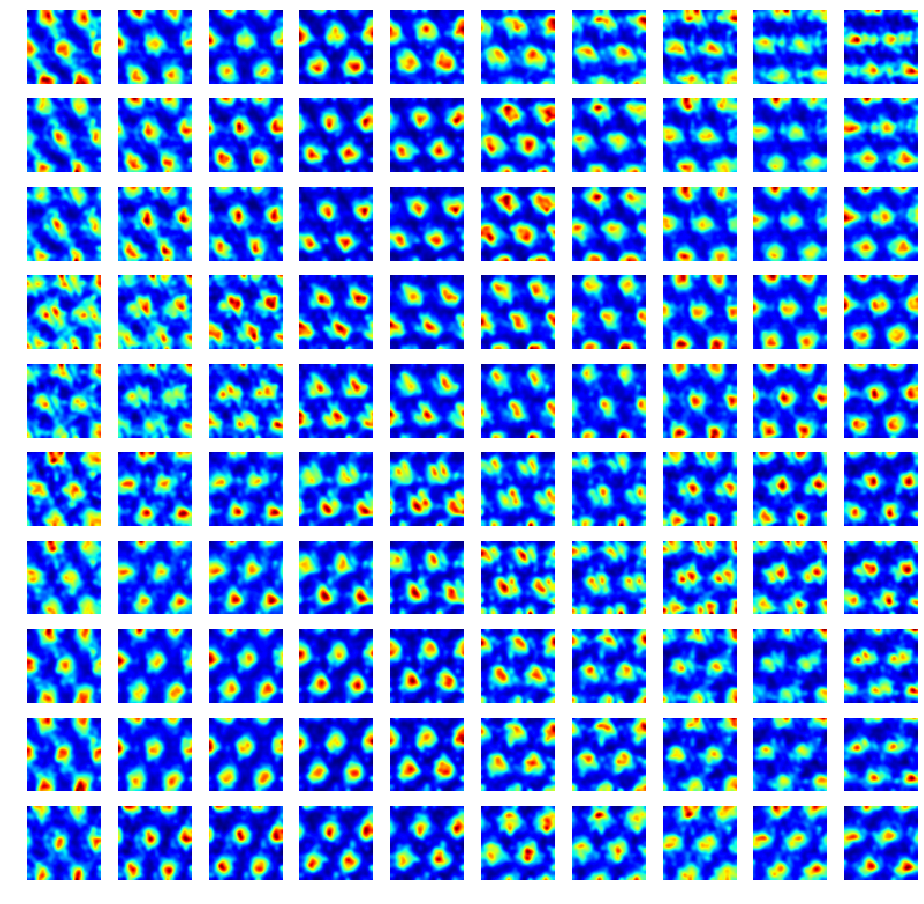

In [41]:
# Skew matrix to transform parallelogram unit cells to squares
A = np.asarray([[2,1],[0, np.sqrt(3)]])/4
Ainv = np.linalg.inv(A)

freq = 2
nplots=10
fig, axes = plt.subplots(nplots,nplots, figsize=(16,16))
for i in range(nplots):
    for j in range(nplots):
        idx = np.ravel_multi_index(((i+nplots//2)*res//nplots//freq,
                                    (j+nplots//2)*res//nplots//freq), (res,res))
        im = rm_sort_square[:,:,idx]
        im = scipy.ndimage.affine_transform(im, Ainv, mode='wrap')
        im = scipy.ndimage.gaussian_filter(im, sigma=(2,2))
        axes[j,i].imshow(im.T, cmap='jet')
        axes[j,i].axis('off')

# Connectivity

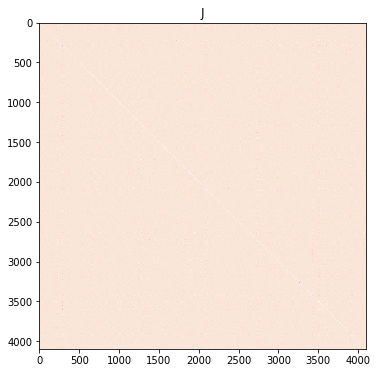

In [42]:
J = model.RNN.weights[1].numpy().T
plt.figure(figsize=(6,6))
plt.imshow(J, cmap='RdBu');
plt.title('J');

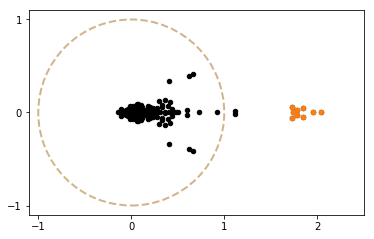

In [44]:
# Eigenvalues
eigs, eigvs = np.linalg.eig(J)

fig, ax = plt.subplots()
plt.scatter(np.real(eigs), np.imag(eigs), c='black', s=20)
plt.scatter(np.real(eigs[:9]), np.imag(eigs[:9]), c='C1', s=20)
circle1 = plt.Circle((0, 0), 1, color='tan',
                     fill=False, linestyle='dashed', linewidth=2)
ax.add_artist(circle1)
plt.xlim([-1.1,2.5])
plt.ylim([-1.1,1.1])
plt.gca().set_aspect('equal', adjustable='box')
plt.locator_params(nbins=4)
# plt.axis('equal')
# sns.despine()
# plt.savefig('images/final_eigs.pdf')

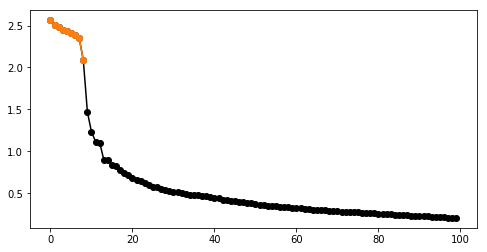

In [45]:
U,S,V = np.linalg.svd(J)

plt.figure(figsize=(8,4))
plt.plot(S[:100], 'o-', c='black')
plt.plot(S[:9], 'o-', c='C1')
# sns.despine();

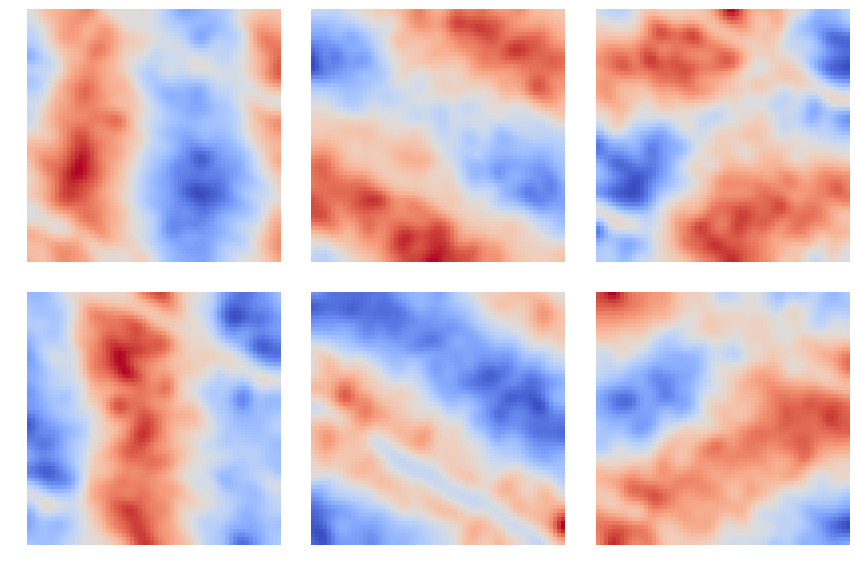

In [79]:
A = np.asarray([[2,1],[0, np.sqrt(3)]])/2
Ainv = np.linalg.inv(A)

plt.figure(figsize=(12,8))
idxs = [1,3,5,4,0,2]
for i in range(6):
    plt.subplot(2,3,i+1)
    im = eigvs_rot[idxs[i]].reshape(n,n)
    im = np.roll(np.roll(im, n//4, axis=1), -n//4, axis=0)
    im = scipy.ndimage.affine_transform(im, Ainv, mode='wrap')
    if i==1 or i==4:
        im = np.roll(im, -n//3, axis=0)
    im = scipy.ndimage.gaussian_filter(im, sigma=(2,2))
    
    plt.imshow(im, cmap='coolwarm')
    plt.axis('off')
plt.tight_layout()
# plt.savefig('images/eigvs2.pdf')

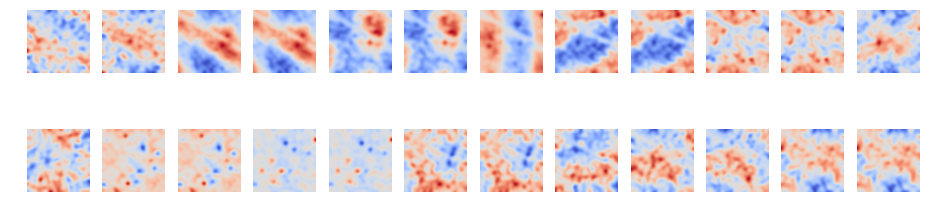

In [80]:
idxs = np.flip(np.argsort(eigs))

A = np.asarray([[2,1],[0, np.sqrt(3)]])/2
Ainv = np.linalg.inv(A)

n = int(np.sqrt(Ng))
plt.figure(figsize=(16,4))
for i in range(24):
    plt.subplot(2,12,i+1)
    idx = idxs[i]
    im = np.real(eigvs[total_order,idx].reshape(n,n))
    im = scipy.ndimage.affine_transform(im, Ainv, mode='wrap')
    im = scipy.ndimage.gaussian_filter(im, sigma=(2,2)) 
    plt.imshow(im, cmap='coolwarm', interpolation='gaussian')
    plt.axis('off')

## Sort weights

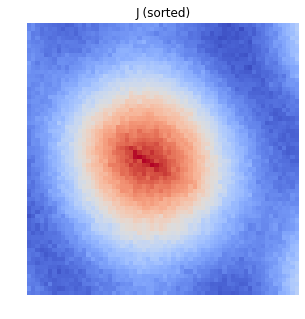

In [81]:
n = int(np.sqrt(Ng))
Jsort = J[total_order][:, total_order]
J_square = np.reshape(Jsort, (n,n,n,n))

Jmean = np.zeros([n,n])
for i in range(n):
    for j in range(n):
        Jmean += np.roll(np.roll(J_square[i,j], -i, axis=0), -j, axis=1)
        
Jmean[0,0] = np.max(Jmean[1:,1:])
Jmean = np.roll(np.roll(Jmean, n//2, axis=0), n//2, axis=1)
# plt.imshow(Jmean, cmap='coolwarm', interpolation='gaussian')

A = np.asarray([[2,1],[0, np.sqrt(3)]])/2
Ainv = np.linalg.inv(A)
im = Jmean
im = scipy.ndimage.affine_transform(Jmean, Ainv, mode='wrap')

imroll = im
imroll = np.roll(np.roll(im, -n//4, axis=0), 0, axis=1)
# imroll = scipy.ndimage.gaussian_filter(imroll, sigma=(1,1))

plt.figure(figsize=(5,5))
plt.imshow(imroll, cmap='coolwarm')
plt.title('J (sorted)')
plt.axis('off');
# plt.savefig('images/rnn_connectivity_sheared.pdf')

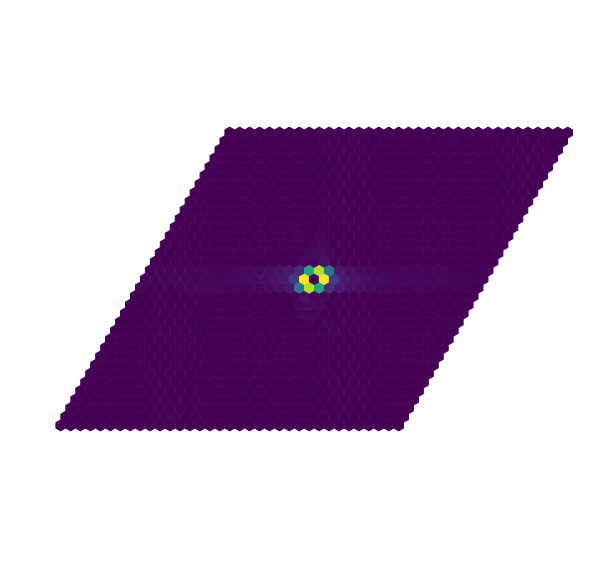

In [82]:
n = int(np.sqrt(N))
width = 18
xs = np.arange(2*width-1)
X,Y = np.meshgrid(xs,xs)
XY = np.stack((X.ravel(),Y.ravel()),0)
T = np.array([[1,0.5],[0,np.sqrt(3)/2]])
XY = T.dot(XY)#+ np.random.randn(*XY.shape)/100 

idxs = np.arange(-width+1, width)
im_fft = np.abs(np.fft.fft2(im))
im_fft[0,0] = 0

plt.figure(figsize=(10,10))
plt.scatter(XY[0],XY[1],s=120,c=im_fft[idxs][:,idxs].ravel(),
            marker='h', cmap='viridis')
plt.axis('equal')
plt.axis('off');
# plt.savefig('images/fft2.pdf')

# Path integration

In [83]:
# Compute JGv
J = model.RNN.weights[1].numpy().T
M = model.RNN.weights[0].numpy().T

theta = 0
v = np.stack([np.cos(theta), np.sin(theta)])

G = (J@rate_map) > 0
# G = rate_map > 0
Mv = M@v
GMv = G*Mv[:,None]
JGMv = J@GMv

# Compute sliding mode
shift = 5
SM = rate_map.reshape(Ng,res,res)
SM = np.roll(SM,shift=-shift,axis=1) - np.roll(SM,shift=shift,axis=1)
SM = SM.reshape(Ng, -1)

# Compute projection and cos ang
proj = tf.reduce_sum(JGMv * SM, axis=0)
cos_ang = proj / np.sqrt((np.sum(SM**2, axis=0) * np.sum(JGMv**2, axis=0)))

Text(0, 0.5, 'Count')

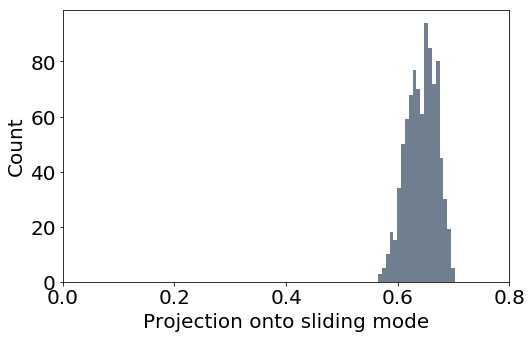

In [87]:
plt.rcParams.update({'font.size': 20})

crop = 10
idxs1, idxs2 = np.mgrid[crop:res-crop, crop:res-crop]
idxs = np.ravel_multi_index((idxs1,idxs2), (res,res)).ravel()
plt.figure(figsize=(8,5))
plt.hist(cos_ang.numpy()[idxs], bins=20, color='slategrey')
plt.xlim([0,0.8]);
# plt.locator_params(nbins=5)
plt.xlabel('Projection onto sliding mode')
plt.ylabel('Count')
# plt.title(r"$\frac{J\sigma'M \cdot \vec s}{\||J\sigma'M\||\ \||\vec s\||}$", fontsize=20);
# plt.savefig(folder+str('JGv.png'), dpi=1000)

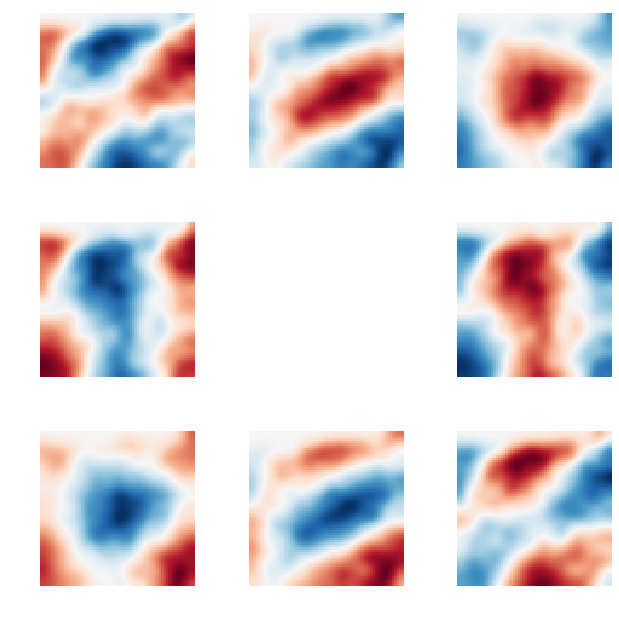

In [88]:
thetas = np.linspace(0,2*np.pi,8, endpoint=False)
clock_idxs = np.roll([0,1,2,5,8,7,6,3], 1)
idx = np.ravel_multi_index((20,20), (res,res))

plt.figure(figsize=(9,9))
for i in range(8):
    theta = thetas[i]
    
    # Get JGMv
    v = np.stack([np.cos(theta), np.sin(theta)])
    Mv = M@v
    GMv = G[:,idx]*Mv
    JGMv = J@GMv
    
    #Plot
    plt.subplot(3,3,clock_idxs[i]+1)
    
    im = JGMv[total_order].reshape(n,n)
    im = scipy.ndimage.gaussian_filter(im, (3,3))
    plt.imshow(im, cmap='RdBu')
    plt.axis('off')
plt.tight_layout()

# SVD

In [74]:
# Perform SVD
import scipy
X = rate_map - rate_map.mean(-1,keepdims=True)
X -= X.mean(-1, keepdims=True)
Ua, S, V = scipy.linalg.svd(X)

rm_embed = Ua.T@rate_map

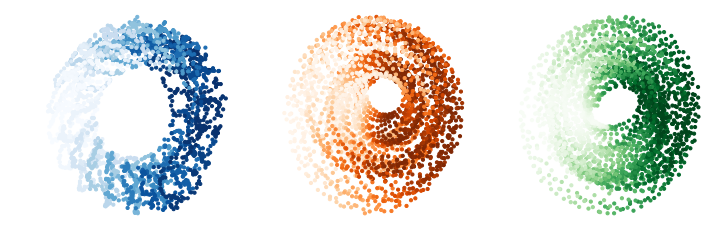

In [75]:
# Construct torus
# k1 = [1,0]
# k2 = [0.5, 0.5*np.sqrt(3)]
# k3 = np.array([-0.5, 0.5*np.sqrt(3)]) 

k1 = [3,0]
k2 = [2,2.5]
k3 = [-1,2.3]

# k1 = [1,0]
# k2 = [2,2.5]
# k3 = [-1,2.3]

freq = 1
x = np.mgrid[:res,:res] * 2*np.pi/ res
x = x.reshape(2, -1)
k = freq*np.stack([k1,k2,k3])
X = np.concatenate([np.cos(k.dot(x)), np.sin(k.dot(x))], axis=0)
cmaps = ['Blues', 'Oranges', 'Greens']

crop = 0
idxs1, idxs2 = np.mgrid[crop:res-crop, crop:res-crop]
idxs = np.ravel_multi_index((idxs1,idxs2), (res,res)).ravel()

# Find rotation
RM = rm_embed[:10, idxs]
X_crop = X[:,idxs]
R = np.linalg.inv(RM.dot(RM.T)).dot(RM).dot(X_crop.T).T

# Lowdin symmetric orthogonalization 
U,s,V = np.linalg.svd(R)
S2 = U.dot(np.diag(1./s)).dot(U.T)
R = S2.dot(R)

# Plot rings
plt.figure(figsize=(12,4))
for i in range(R.shape[0]//2):
    plt.subplot(1,3,i+1)
    plt.scatter(R.dot(RM)[i], R.dot(RM)[i+3], c=X[i][idxs], cmap=cmaps[i], s=10)
    plt.axis('off')
    
# plt.savefig(folder + 'ring_fit.png')

# Null model (low-pass filtered noise)

In [1175]:
# res = 50
# coords = np.arange(resolution)*2*np.pi/res
# x, y = np.meshgrid(coords, coords)
# x = x.ravel(); y = y.ravel()
# k1, k2 = np.meshgrid(np.arange(-3,4),np.arange(-3,4))
# grid = k1[..., None]*x + k2[..., None]*y

# X = np.cos(grid)
# Y = np.sin(grid)
# H = np.stack([X, Y], axis=0).reshape(-1, (resolution)**2)

# Ng = 100
# pattern = np.random.randn(Ng,98).dot(H)

In [1176]:
# Construct filter
max_freq = 3
min_freq = 0
x, y = np.meshgrid(np.arange(res), np.arange(res))
r = np.sqrt((x-res//2)**2 + (y-res//2)**2)
filt = np.greater(max_freq - r, 0) * np.greater(r-min_freq,0)
# sigma = 5
# filt = np.exp(-r**2/2/sigma) * filt1

# Make random noise patterns
N = 4096
noise = np.random.randn(N, res, res)

# Convolve with filter
noise_tilde = np.fft.fftshift(np.fft.fft2(noise))
noise_tilde_filt = noise_tilde * filt
patterns = np.real(np.fft.ifft2(np.fft.ifftshift(noise_tilde_filt)))

In [ ]:
# Fourier transform 
rm_fft_real = np.zeros([N,res,res])
rm_fft_imag = np.zeros([N,res,res])

for i in tqdm(range(N)):
    rm_fft_real[i] = np.real(np.fft.fft2(patterns[i].reshape([res,res])))
    rm_fft_imag[i] = np.imag(np.fft.fft2(patterns[i].reshape([res,res])))
    
rm_fft = rm_fft_real + 1j * rm_fft_imag

In [1178]:
k1 = [3,0]
k2 = [2,3]
k3 = [-1,3]
k4=k5=k6=k1

freq = 1
ks = freq*np.array([k1,k2,k3,k4,k5,k6])
ks = ks.astype('int')

modes = np.stack([rm_fft[:,k[0],k[1]] for k in ks])
# Find phases
phases = [np.angle(mode) for mode in modes]

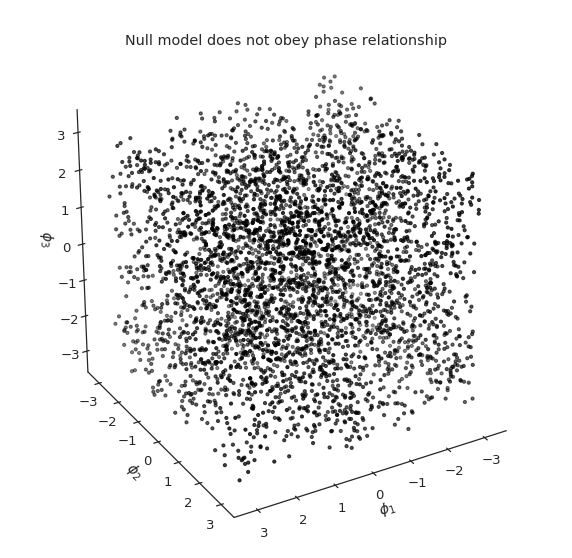

In [1191]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(phases[0], phases[1], phases[2], c='black', s=10)
ax.view_init(azim=60)
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.xaxis._axinfo["grid"]['color'] =  (1,1,1,0)
ax.yaxis._axinfo["grid"]['color'] =  (1,1,1,0)
ax.zaxis._axinfo["grid"]['color'] =  (1,1,1,0)
ax.set_xlabel(r'$\phi_1$')
ax.set_ylabel(r'$\phi_2$')
ax.set_zlabel(r'$\phi_3$')
plt.title('Null model does not obey phase relationship');

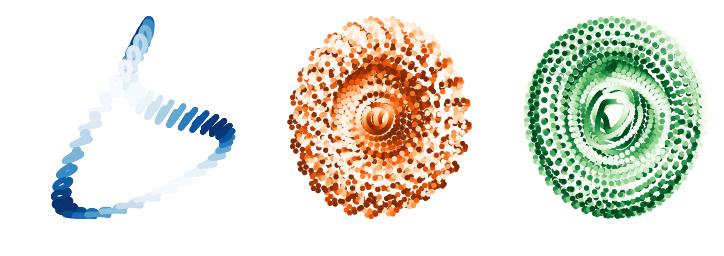

In [1180]:
crop = 0
freq = 1
x = np.mgrid[:res,:res] * 2*np.pi/ res
x = x.reshape(2, -1)
k = freq*np.stack([k1,k2,k3])
X = np.concatenate([np.cos(k.dot(x)), np.sin(k.dot(x))], axis=0)
idxs1, idxs2 = np.mgrid[crop:res-crop, crop:res-crop]
idxs = np.ravel_multi_index((idxs1,idxs2), (res,res)).ravel()

plt.figure(figsize=(12,4))
for i in range(3):
    plt.subplot(1,3,i+1)
    B = np.stack([np.cos(phases[i]), np.sin(phases[i])])
    test = B@patterns.reshape(N,-1)
    plt.scatter(test[0], test[1], c=X[i][idxs], cmap=cmaps[i], s=20)
    plt.axis('off')

# Boundary extension

In [1195]:
options.sequence_length = 80
options.box_width = 4.4
options.box_height = 4.4
trajectory_generator = TrajectoryGenerator(options, place_cells)

In [1197]:
from visualize import compute_ratemaps, plot_ratemaps
res = 50
n_avg = 10
Ng = options.Ng
activations, rate_map, g, pos = compute_ratemaps(model,
                                                 trajectory_generator,
                                                 options,
                                                 res=res,
                                                 n_avg=n_avg,
                                                 Ng=Ng)

n_plot = 256
plt.figure(figsize=(16,4*n_plot//8**2))
rm_fig = plot_ratemaps(activations, n_plot, smooth=True)
plt.imshow(rm_fig)
plt.axis('off');

# Head direction and speed tuning

In [ ]:
g = []
vs = []
hds = []
navg = 100
for index in tqdm(range(n_avg), leave=False, desc='Computing ratemaps'):
    inputs, pos_batch, _ = trajectory_generator.get_test_batch()
    v = inputs[0].cpu().numpy()
    g_batch = model.g(inputs).detach().cpu().numpy()

    vx,vy = v[:,:,0], v[:,:,1]
    v = np.sqrt(vx**2 + vy**2)
    hd = np.arctan2(vy,vx)
    g_batch = np.reshape(g_batch, (-1,Ng))

    g.append(g_batch)
    vs.append(v.ravel())
    hds.append(hd)

g = np.stack(g).reshape([-1, Ng])
vs = np.stack(vs).ravel()
hds = np.stack(hds).ravel()

In [201]:
# Construct speed tuning curves
speed_curves = []
speed_scores = []
for i in tqdm(range(Ng)):
    stat,bins,_ = scipy.stats.binned_statistic(vs,g[:,i], bins=10, range=(0,0.05))
    speed_curves.append(stat)
    speed_scores.append(np.corrcoef(vs, g[:,i])[0,1])
speed_curves = np.stack(speed_curves)

100%|██████████| 4096/4096 [03:26<00:00, 19.86it/s]


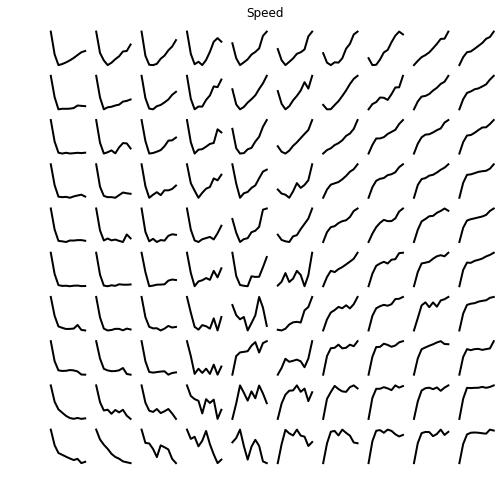

In [362]:
# Plot a sampling of tuning curves in 2d PCA space
nplot = 10
U,S,V = np.linalg.svd(speed_curves - speed_curves.mean(-1,keepdims=True))
x = -U[:,1]
y = -U[:,0]
x = (x+np.abs(x.min))
x = nplot*x/x.max()
y = (y+np.abs(y.min))
y = nplot*y/y.max()
# x = nplot*(scipy.special.erf((x-x.mean())/x.std())+1)/2
# y = nplot*(scipy.special.erf((y-y.mean())/y.std())+1)/2

plt.figure(figsize=(8,8))
for i in range(nplot):
    for j in range(nplot):
        plt.subplot(nplot,nplot,i*nplot+j+1)
        candidates = (x>i)*(x<i+1)*(y>j)*(y<j+1)
        idxs = np.arange(Ng)[candidates]
        try:
            plt.plot(speed_curves[np.random.choice(idxs)], c='black', linewidth=2)
        except:
            pass
        plt.axis('off')
plt.suptitle('Speed', y=0.92)
# plt.savefig('images/speed_tuning_pca.pdf')

In [ ]:
# Construct head direction tuning curves
hd_curves = []
hd_scores = []
for i in tqdm(range(Ng)):
    stat,bins,_ = scipy.stats.binned_statistic(hds,g[:,i], bins=10, range=(-np.pi,np.pi))
    hd_curves.append(stat)
    hd_scores.append(np.corrcoef(hds, g[:,i])[0,1])
hd_curves = np.stack(hd_curves)

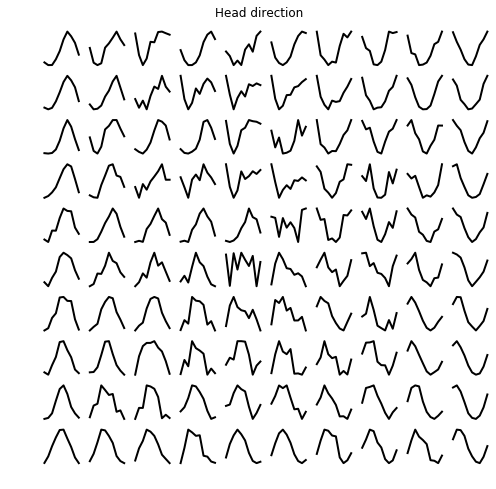

In [361]:
# Plot a sampling of tuning curves in 2d PCA space
nplot = 10
U,S,V = np.linalg.svd(hd_curves - hd_curves.mean(-1,keepdims=True))
x = -U[:,1]
y = -U[:,0]
x = nplot*(scipy.special.erf((x-x.mean())/x.std())+1)/2
y = nplot*(scipy.special.erf((y-y.mean())/y.std())+1)/2

plt.figure(figsize=(8,8))
for i in range(nplot):
    for j in range(nplot):
        plt.subplot(nplot,nplot,i*nplot+j+1)
        candidates = (x>i)*(x<i+1)*(y>j)*(y<j+1)
        idxs = np.arange(Ng)[candidates]
        try:
            plt.plot(hd_curves[np.random.choice(idxs)], c='black', linewidth=2)
        except:
            pass
        plt.axis('off')
plt.suptitle('Head direction', y=0.92)
# plt.savefig('images/hd_tuning_pca.pdf')

In [363]:
# Plot position tuning curves in 2d space

In [1053]:
U,S,V = np.linalg.svd(rate_map - rate_map.mean(-1,keepdims=True))

In [863]:
import seaborn as sns
sns.set(font_scale=1.2, style='ticks')

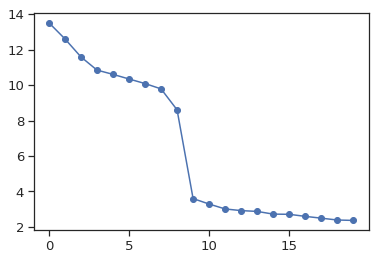

In [1054]:
plt.plot(S[:20], 'o-')

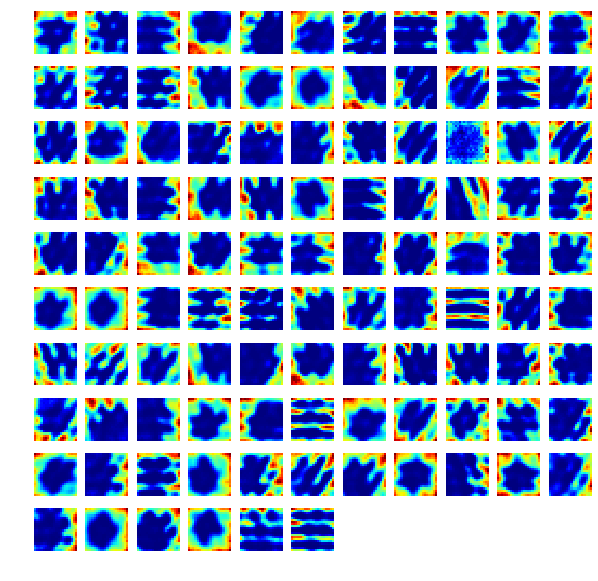

In [1042]:
idxs = np.where(border_scores>0.6)[0]

plt.figure(figsize=(10,10))
for i,idx in enumerate(idxs):
    plt.subplot(10,11,i+1)
    plt.imshow(rate_map[idx].reshape(res,res), cmap='jet')
    plt.axis('off')

<Figure size 288x288 with 0 Axes>

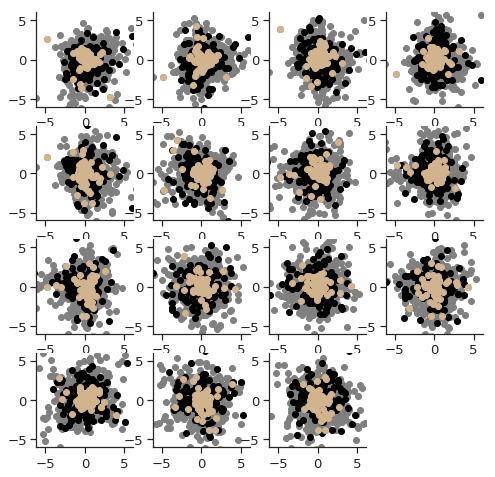

In [1056]:
plt.figure(figsize=(4,4))
counter = 0
plt.figure(figsize=(8,8))
for i in range(6):
    for j in range(i+1,6):
        counter+=1
        plt.subplot(4,4,counter)
        x = U[:,i]
        x = (x-x.mean())/x.std()
        y = U[:,j]
        y = (y-y.mean())/y.std()

        # n = (score_60<0.3).sum()
        # idxs = np.random.choice(np.arange(n), 523)
        plt.scatter(x[grid_sort[score_60<1]], y[grid_sort[score_60<1]], c='grey')
        plt.scatter(x[grid_sort[score_60>1]], y[grid_sort[score_60>1]], c='black')
        plt.scatter(x[grid_sort[border_scores>0.6]], y[grid_sort[border_scores>0.6]], c='tan')
        plt.axis('equal')
        plt.xlim([-6,6])
        plt.ylim([-6,6])
        sns.despine();

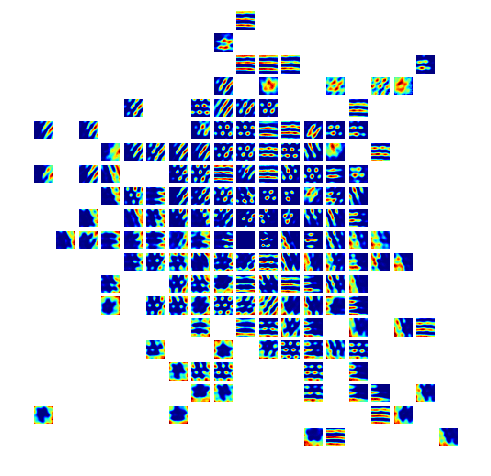

In [1043]:
nplot = 20
x = U[:,2]
y = U[:,1]
x = nplot*(x+0.1)/0.2
y = nplot*(y+0.1)/0.2
# x = x + np.abs(x.min())
# x = nplot*x/np.max(x)
# y = y + np.abs(y.min())
# y = nplot*y/np.max(y)
# x = nplot*(scipy.special.erf((x-x.mean())/x.std())+1)/2
# y = nplot*(scipy.special.erf((y-y.mean())/y.std())+1)/2

plt.figure(figsize=(8,8))
for i in range(nplot):
    for j in range(nplot):
        plt.subplot(nplot,nplot,i*nplot+j+1)
        candidates = (x>i)*(x<i+1)*(y>j)*(y<j+1)
        idxs = np.arange(Ng)[candidates]
        try:
            plt.imshow(rate_map[np.random.choice(idxs)].reshape(res,res),
                      cmap='jet')
        except:
            pass
        plt.axis('off')
# plt.savefig('images/rate_maps_pca.pdf')

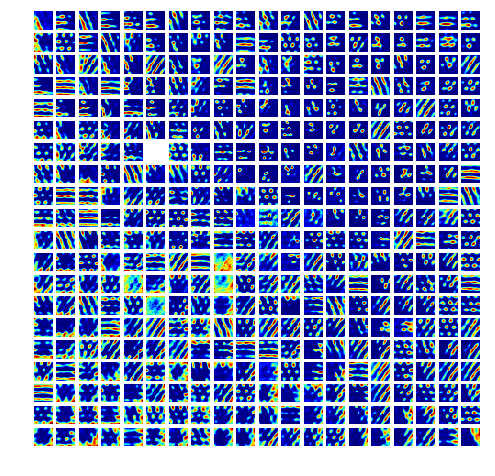

In [1057]:
nplot = 20
x = U[:,0]
y = U[:,1]
x = nplot*(scipy.special.erf((x-x.mean())/x.std())+1)/2
y = nplot*(scipy.special.erf((y-y.mean())/y.std())+1)/2

plt.figure(figsize=(8,8))
for i in range(nplot):
    for j in range(nplot):
        plt.subplot(nplot,nplot,i*nplot+j+1)
        candidates = (x>i)*(x<i+1)*(y>j)*(y<j+1)
        idxs = np.arange(Ng)[candidates]
        try:
            plt.imshow(rate_map[np.random.choice(idxs)].reshape(res,res),
                      cmap='jet')
        except:
            pass
        plt.axis('off')
# plt.savefig('images/rate_maps_pca.pdf')

# Border score

In [1151]:
from scores import border_score

In [ ]:
border_scores = []
cms = []
dms = []
for i in tqdm(range(Ng)):
    rm = rate_map[i].reshape(res,res)
    bscore, cm, dm = border_score(rm, res, options.box_width)
    border_scores.append(bscore)
    cms.append(cm)
    dms.append(dm)
border_scores = np.stack(border_scores)

(array([  90.,  388.,  957., 1077.,  455.,  359.,  253.,   60.,   21.,
           9.]),
 array([0.05329684, 0.13985784, 0.22641884, 0.31297984, 0.39954084,
        0.48610184, 0.57266285, 0.65922385, 0.74578485, 0.83234585,
        0.91890685]),
 <a list of 10 Patch objects>)

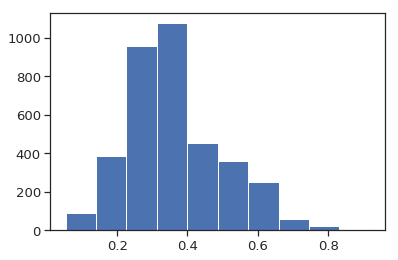

In [1153]:
plt.hist(dms)

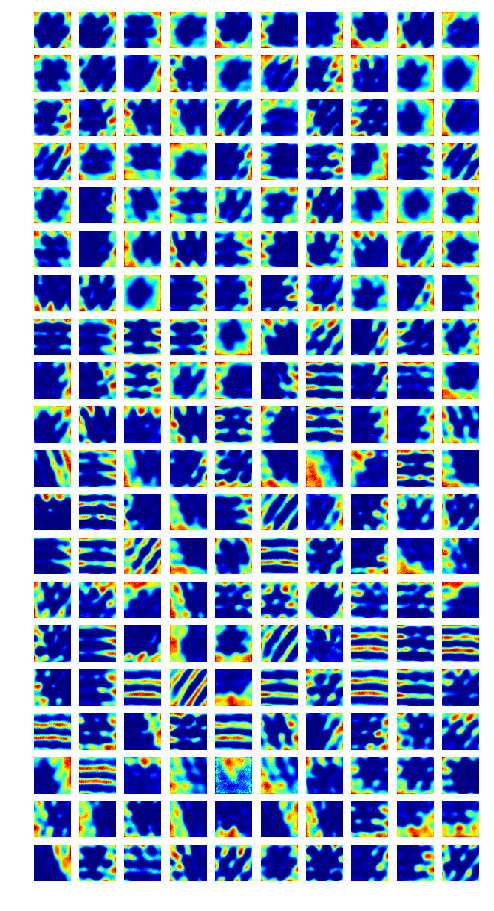

In [1156]:
border_sort = np.argsort(np.nan_to_num(border_scores))
plt.figure(figsize=(8,16))
for i in range(200):
    plt.subplot(20,10,i+1)
    plt.imshow(rate_map[border_sort[-1-i]].reshape(res,res), cmap='jet')
    plt.axis('off')

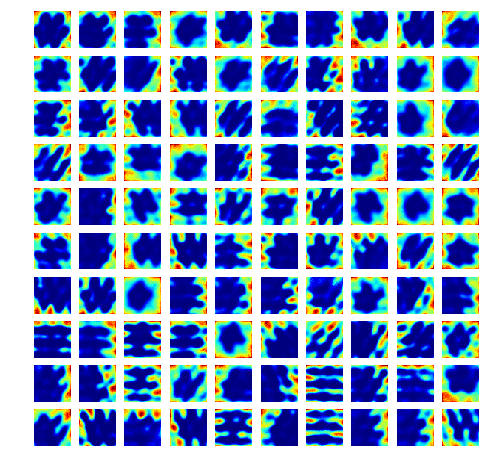

In [1142]:
border_sort = np.argsort(np.nan_to_num(border_scores))
plt.figure(figsize=(8,8))
for i in range(100):
    plt.subplot(10,10,i+1)
    plt.imshow(rate_map[border_sort[-1-i]].reshape(res,res), cmap='jet')
    plt.axis('off')

In [884]:
rm = rate_map[border_sort[-4]].reshape(res,res)

# Keep fields with area > 200cm^2
masks = []
nfields = 0
for i in range(1,ncomps+1):
    mask = (rm_comps==i).reshape(res,res)
    if mask.sum()*pix_area > 800:
        masks.append(mask)
        nfields += 1